# Software Anomaly Detection
This notebook implements LOF for anomaly detection.

In [ ]:
from google.colab import files
import pandas as pd

# Upload file dari komputer
uploaded = files.upload()

# Baca file CSV ke dalam dataframe
filename = list(uploaded.keys())[0]  # Ambil nama file yang diupload
df = pd.read_csv(filename)

# Tampilkan beberapa data pertama
df.head()

In [ ]:
import pandas as pd

# Define the file path
file_path = 'Software_License_Filtered.csv'

# Load dataset
df = pd.read_csv(file_path)

# Cek jumlah baris dan kolom
print(f"Dataset shape: {df.shape}")

# Cek tipe data tiap kolom
print("\nInfo dataset:")
print(df.info())

# Cek jumlah missing values di tiap kolom
print("\nMissing values per column:")
print(df.isnull().sum())

# Tampilkan sampel data
print("\nSample data:")
print(df.head())

In [ ]:
# Load ulang data yang sudah difilter
df = pd.read_csv("Software_License_Filtered.csv")

# Drop kolom yang tidak diperlukan (jika ada)
kolom_drop = ["Serial_Number", "Installation_Date"]  # Contoh, bisa disesuaikan
df = df.drop(columns=[col for col in kolom_drop if col in df.columns])

# Cek missing values
df = df.dropna()  # Hapus baris dengan nilai kosong

# Standarisasi teks (misal, di kolom "Product_Name")
df["Product_Name"] = df["Product_Name"].str.lower().str.strip()

# Simpan hasil preprocessing
df.to_csv("Software_License_Preprocessed.csv", index=False)

# Konfirmasi hasil
print("✅ Data preprocessing selesai! File disimpan sebagai Software_License_Preprocessed.csv.")

✅ Data preprocessing selesai! File disimpan sebagai Software_License_Preprocessed.csv.


In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load dataset hasil preprocessing
df = pd.read_csv("Software_License_Preprocessed.csv")

# Pilih fitur yang akan digunakan
fitur_terpilih = ["Product_Name", "Publisher", "License_Code"]
df_filtered = df[fitur_terpilih].copy()

# Encode fitur kategorikal menjadi numerik
encoder = LabelEncoder()
for col in fitur_terpilih:
    df_filtered[col] = encoder.fit_transform(df_filtered[col])

# Inisialisasi & jalankan Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df_filtered["Anomaly"] = lof.fit_predict(df_filtered)

# Gabungkan kembali dengan data asli
df["Anomaly_LOF"] = df_filtered["Anomaly"]

# Pisahkan anomali & normal
anomali_df = df[df["Anomaly_LOF"] == -1]  # Software yang terdeteksi anomali
normal_df = df[df["Anomaly_LOF"] == 1]  # Software yang dianggap normal

# Simpan hasil anomali
anomali_df.to_csv("Software_Anomalies_LOF.csv", index=False)
print(f"✅ Deteksi anomali selesai! Ditemukan {len(anomali_df)} software mencurigakan menggunakan LOF.")

✅ Deteksi anomali selesai! Ditemukan 29 software mencurigakan menggunakan LOF.


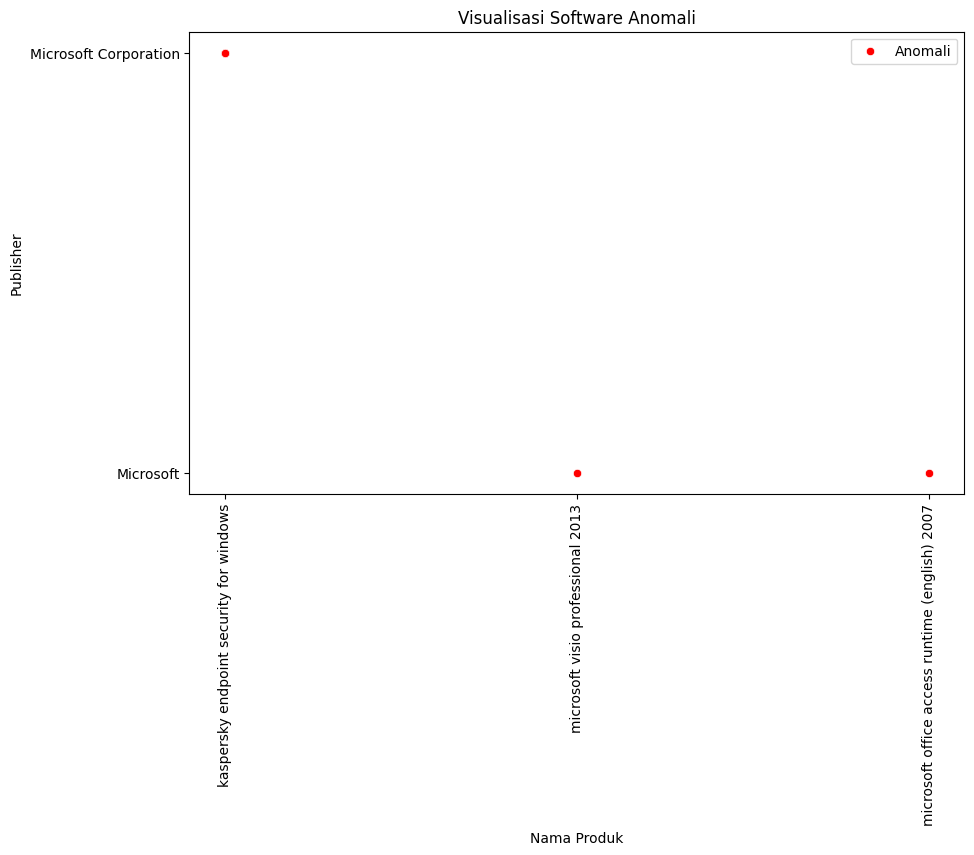

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load kembali data hasil deteksi anomali
df_anomali = pd.read_csv("Software_Anomalies_LOF.csv")

# Plot scatter untuk melihat distribusi anomali
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_anomali, x="Product_Name", y="Publisher", color="red", label="Anomali")
plt.xticks(rotation=90)
plt.xlabel("Nama Produk")
plt.ylabel("Publisher")
plt.title("Visualisasi Software Anomali")
plt.legend()
plt.show()

<ipython-input-10-1b96f88d5fa5>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_anomalies.values, y=top_anomalies.index, palette="Reds_r")


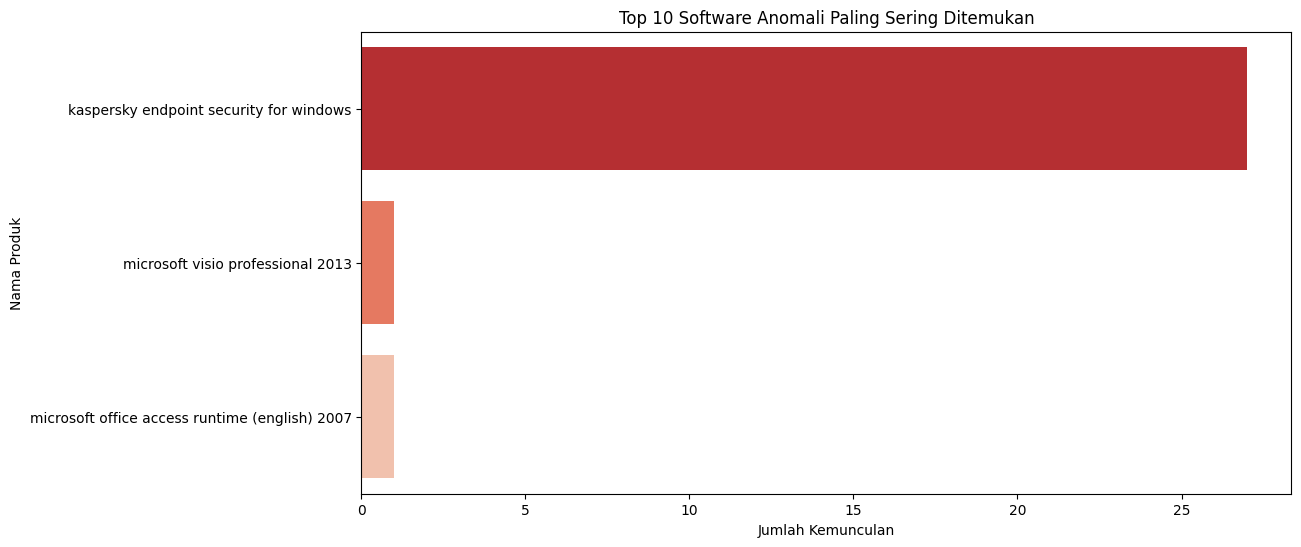

In [ ]:
# Hitung jumlah kemunculan setiap product_name yang terdeteksi sebagai anomali
top_anomalies = df_anomali["Product_Name"].value_counts().nlargest(10)

# Plot bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_anomalies.values, y=top_anomalies.index, palette="Reds_r")
plt.xlabel("Jumlah Kemunculan")
plt.ylabel("Nama Produk")
plt.title("Top 10 Software Anomali Paling Sering Ditemukan")
plt.show()

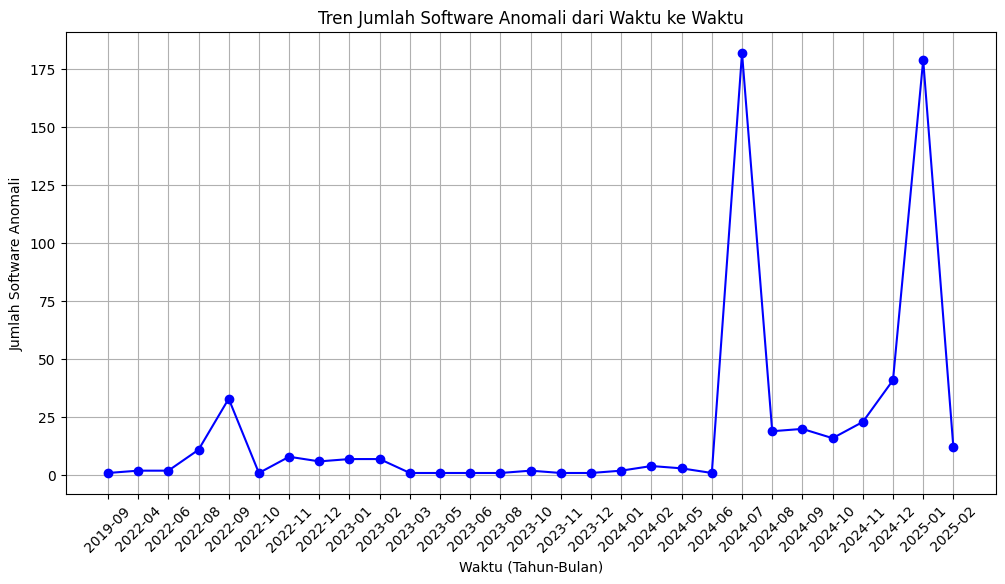

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Drop baris dengan Install_Date NaN
df_cleaned = df.dropna(subset=["Install_Date"])

# Convert 'Install_Date' to datetime if it's not already
df_cleaned["Install_Date"] = pd.to_datetime(df_cleaned["Install_Date"])

# Kelompokkan jumlah software anomali per bulan
df_cleaned["Year-Month"] = df_cleaned["Install_Date"].dt.to_period("M")
anomaly_trend = df_cleaned.groupby("Year-Month").size()

# Visualisasi tren
plt.figure(figsize=(12, 6))
plt.plot(anomaly_trend.index.astype(str), anomaly_trend.values, marker="o", linestyle="-", color="b")

# Formatting chart
plt.xticks(rotation=45)
plt.xlabel("Waktu (Tahun-Bulan)")
plt.ylabel("Jumlah Software Anomali")
plt.title("Tren Jumlah Software Anomali dari Waktu ke Waktu")
plt.grid(True)
plt.show()

In [ ]:
import os

# Simpan hasil anomali ke CSV
output_file = "/mnt/data/Software_Anomalies_LOF.csv"

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(output_file), exist_ok=True)

df_anomali.to_csv(output_file, index=False)

# Link untuk download
from google.colab import files
files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>